In [2]:
%%html
<style>
    /* Target tables inside markdown-rendered cells */
    .jp-RenderedMarkdown table,
    .jp-RenderedMarkdown th,
    .jp-RenderedMarkdown td {
        border: 1px solid black;
        border-collapse: collapse;
    }
    .jp-RenderedMarkdown th,
    .jp-RenderedMarkdown td {
        padding: 6px;
    }
</style>

In [3]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics
import glob


plt.rc("figure", figsize=(8, 6))
plt.rc("figure", dpi=100)

<!-- ### Results: -->
<h3 align="center"><u>Results Table</u></h3> 

| Simulation | Flux | $l_{\text{bulk}}$ \[R] | $l_{\text{bulk}}$ \[Hp] | $l_{\text{max}}$ \[R] | $l_{\text{max}}$ \[Hp] |
| :- | :- | :-: | :-: | :-: | :-: |
| Om0 | $F_{\text{kin}}$ | 0.002819749928542785 | 0.03553541850099051 | 0.012721973884259028 | 0.16032650899433623
| Om0 | $F_{\text{enth}}$ | 0.0018703194087469714 | 0.02357038010860988 | 0.016348529040121053 | 0.2060295519487236
| Om1 | $F_{\text{kin}}$ | 0.0028525834417164075 | 0.035949159201045605 | 0.012361090836583002 | 0.1557783817156549
| Om1 | $F_{\text{enth}}$ | 0.0019500601688288493 | 0.024575274163761884 | 0.0170418464484795 | 0.21476674768261814
| Om5 | $F_{\text{kin}}$ | 0.0030920630963700456 | 0.038967125535529216 | 0.01313109849417339 | 0.16548212795308934
| Om5 | $F_{\text{enth}}$ | 0.002413628818482439 | 0.03041729082406719 | 0.017353809140854198 | 0.2186980257420939

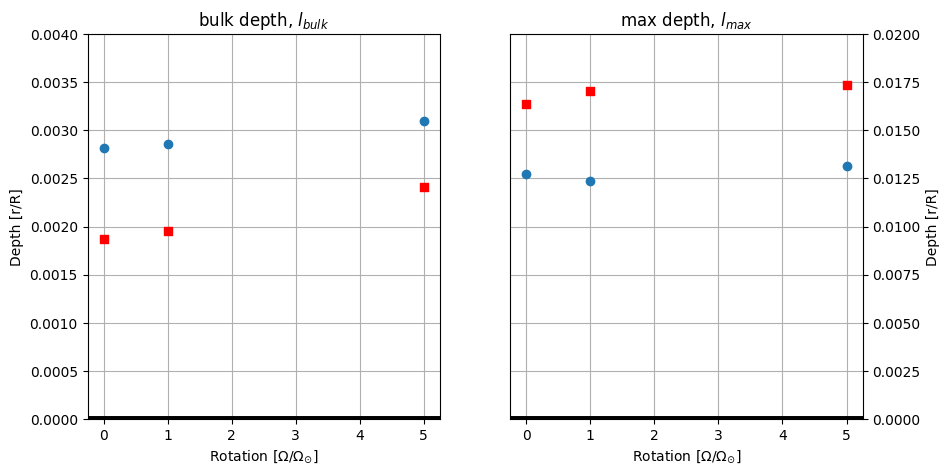

In [4]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))

ax1.grid(zorder=0)
ax2.grid(zorder=0)

x = [0, 1, 5]

Kin_bulk = [0.002819749928542785, 0.0028525834417164075, 0.0030920630963700456]
ax1.scatter(x, Kin_bulk,zorder=3)

Enth_bulk = [0.0018703194087469714, 0.0019500601688288493, 0.002413628818482439]
ax1.scatter(x, Enth_bulk, c='r', marker='s',zorder=3)

Kin_max = [0.012721973884259028, 0.012361090836583002, 0.01313109849417339]
ax2.scatter(x, Kin_max,zorder=3)

Enth_max = [0.016348529040121053, 0.0170418464484795, 0.017353809140854198]
ax2.scatter(x, Enth_max, c='r', marker='s',zorder=3)

ax1.set_xlabel('Rotation [$\Omega/\Omega_{\odot}$]')
ax2.set_xlabel('Rotation [$\Omega/\Omega_{\odot}$]')
ax1.set_ylabel('Depth [r/R]')
ax2.set_ylabel('Depth [r/R]')
ax1.set_ylim(0,0.004)
ax2.set_ylim(0,0.02)
ax1.set_title('bulk depth, $l_{bulk}$')
ax2.set_title('max depth, $l_{max}$')

ax1.axhline(y=0,color='k',linewidth=5)
ax2.axhline(y=0,color='k',linewidth=5)

ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
fig.savefig("depths.png")

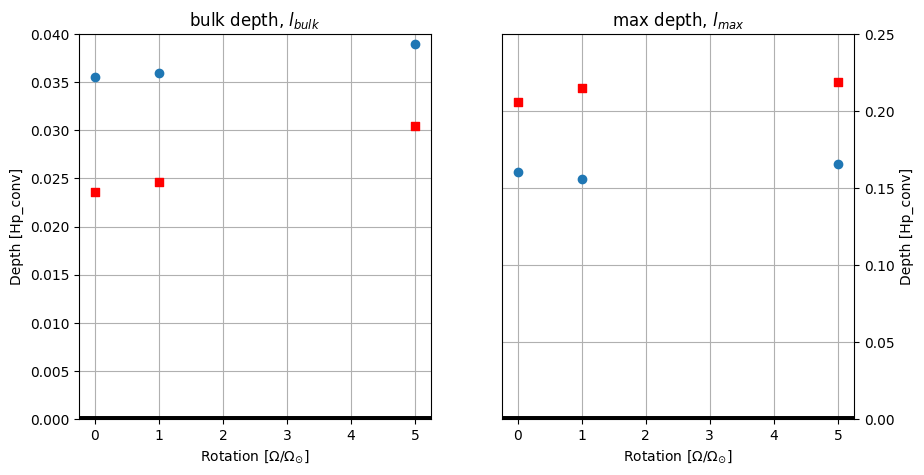

In [7]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))

ax1.grid(zorder=0)
ax2.grid(zorder=0)

x = [0, 1, 5]

Kin_bulk = [0.03553541850099051, 0.035949159201045605, 0.038967125535529216]
ax1.scatter(x, Kin_bulk,zorder=3)

Enth_bulk = [0.02357038010860988, 0.024575274163761884, 0.03041729082406719]
ax1.scatter(x, Enth_bulk, c='r', marker='s',zorder=3)

Kin_max = [0.16032650899433623, 0.1557783817156549, 0.16548212795308934]
ax2.scatter(x, Kin_max,zorder=3)

Enth_max = [0.2060295519487236, 0.21476674768261814, 0.2186980257420939]
ax2.scatter(x, Enth_max, c='r', marker='s',zorder=3)

ax1.set_xlabel('Rotation [$\Omega/\Omega_{\odot}$]')
ax2.set_xlabel('Rotation [$\Omega/\Omega_{\odot}$]')
ax1.set_ylabel('Depth [Hp_conv]')
ax2.set_ylabel('Depth [Hp_conv]')
ax1.set_ylim(0,0.04)
ax2.set_ylim(0,0.25)
ax1.set_title('bulk depth, $l_{bulk}$')
ax2.set_title('max depth, $l_{max}$')

ax1.axhline(y=0,color='k',linewidth=5)
ax2.axhline(y=0,color='k',linewidth=5)

ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
fig.savefig("depths_Hp.png")

In [6]:
# parameters used for the simulation
r_tot = 70774597466.3827
r_bot = 0.4 * r_tot
r_top = 0.9 * r_tot
Nr = 504
Ntheta = 360
Nphi = 720
dr_grid = (r_top - r_bot) / Nr
r_conv = 5.149819426617924E+10

In [21]:
#PATTERN= "/Users/ibaraffe/music_plotdir/krad_mesa_20msundir/zero_avtijt1.52d8-8.45d8_307x313_krad_20msun_r0.12-0.27_t45-135_msy0.55_evY_t1.52d8-8.4d8_newlscaledir/zero.cont*"
# PATTERN= "/Users/ibaraffe/music_plotdir/krad_mesa_20msundir/zero_avtij_t1.52d8-1.87d8_307x313x43_20msun_r0.12-0.27_t45-135phi22_msy0.55_evYdir/zero.cont*"
# PATTERN= "/z2/users/cj517/lscaledir_3D/r_min0.4_r_max0.9_from2d_v0_Om0/zerodir/*"
# PATTERN= "/z2/users/cj517/lscaledir_3D/r_min0.4_r_max0.9_from2d_v0_Om1/zerodir/*"
PATTERN= "/z2/users/cj517/lscaledir_3D/r_min0.4_r_max0.9_from2d_v0_Om5/zerodir/*"
all_files = sorted(glob.glob(PATTERN))
# all_files[0:1]

In [22]:
save_dir = 'Om5/'

In [23]:
# Select a subset of files
# subset_files = all_files[0:1]
#subset_files = all_files[0::10]
subset_files = all_files
print("Will process {} files out of {}".format(len(subset_files), len(all_files)))
print("First file is:", subset_files[0])
print("Last file is:", subset_files[-1])
ncount=len(all_files)
print("ncount= ",ncount)

Will process 1501 files out of 1501
First file is: /z2/users/cj517/lscaledir_3D/r_min0.4_r_max0.9_from2d_v0_Om5/zerodir/zero.cont000002000
Last file is: /z2/users/cj517/lscaledir_3D/r_min0.4_r_max0.9_from2d_v0_Om5/zerodir/zero.cont000003500
ncount=  1501


In [24]:
def read_file(fname):
    if int(fname[-4:]) % 50 == 0:
        print(fname[-4:])
    with open(fname, 'r') as f:
        t = float(f.readline())
        df = pd.read_csv(f, sep='\s+',
                    #names=["num_theta", "theta_deg", "HP1", "r1", "renv", "HP2", "r21", "rcore"])
        #names=["num_theta", "theta_deg", "HP1", "r1", "renv", "HP2", "r21", "rcore", "renvdown", "renvup", "rcoredown", "rcoreup"])
        names=["num_phi", "phi_deg", "num_theta", "theta_deg", "HP1", "r1", "r2","r3","r4","r5", "HP2", "r21", "r22","r23","r24","r25"],
        usecols=["num_phi", "phi_deg", "num_theta", "theta_deg", "HP1", "r1", "r2"])
        df["time"] = t
        return df
# r21=zerok (Kin. flux)  
# r22=zeroc (heat flux fluxcr using horizontal average T(i,t))     r23=zeroc1 (heat flux fluxcr1  usint T init)
# r24=zeroc2  (heat flux fluxcr2 using time/horizontal average <T(i)>=avtar(i))  
# r25=zeroc3 (heat flux fluxcr3 using time average of T(i,j) <T(i,j)>=avt(i,j))

In [25]:
all_data = pd.concat([read_file(f) for f in subset_files], ignore_index=True)
print('ALL_DATA_CONCAT: DONE')
all_data = all_data.set_index(["time", "num_theta"]).sort_index()

2000
2050
2100
2150
2200
2250
2300
2350
2400
2450
2500
2550
2600
2650
2700
2750
2800
2850
2900
2950
3000
3050
3100
3150
3200
3250
3300
3350
3400
3450
3500
ALL_DATA_CONCAT: DONE


In [26]:
all_data.dtypes

num_phi        int64
phi_deg      float64
theta_deg    float64
HP1          float64
r1           float64
r2           float64
dtype: object

In [27]:
all_data

num_phi  phi_deg  theta_deg           HP1            r1  \
time       num_theta                                                            
19999950.0 1                1      0.2       30.2  5.615975e+09  5.144499e+10   
           1                2      0.5       30.2  5.615974e+09  5.144499e+10   
           1                3      0.8       30.2  5.615974e+09  5.144499e+10   
           1                4      1.2       30.2  5.615974e+09  5.144499e+10   
           1                5      1.5       30.2  5.615973e+09  5.144499e+10   
...                       ...      ...        ...           ...           ...   
27500170.0 360            716    238.5      149.8  5.615976e+09  5.137477e+10   
           360            717    238.8      149.8  5.615978e+09  5.137477e+10   
           360            718    239.2      149.8  5.615979e+09  5.137477e+10   
           360            719    239.5      149.8  5.615980e+09  5.137477e+10   
           360            720    239.8      149.8  5.615980e+09  5.137477e+10   

                                r2  
time       num_theta                
19999950.0 1          5.144499e+10  
           1          5.144499e+10  
           1          5.144499e+10  
           1          5.144499e+10  
           1          5.144499e+10  
...                            ...  
27500170.0 360        5.137477e+10  
           360        5.137477e+10  
           360        5.137477e+10  
           360        5.137477e+10  
           360        5.137477e+10  

[389059038 rows x 6 columns]

In [28]:
Hp_conv = all_data['HP1']

## Histograms

Mean depth [R]= 0.0030920630963700456 Mean depth [Hp_conv]= 0.038967125535529216


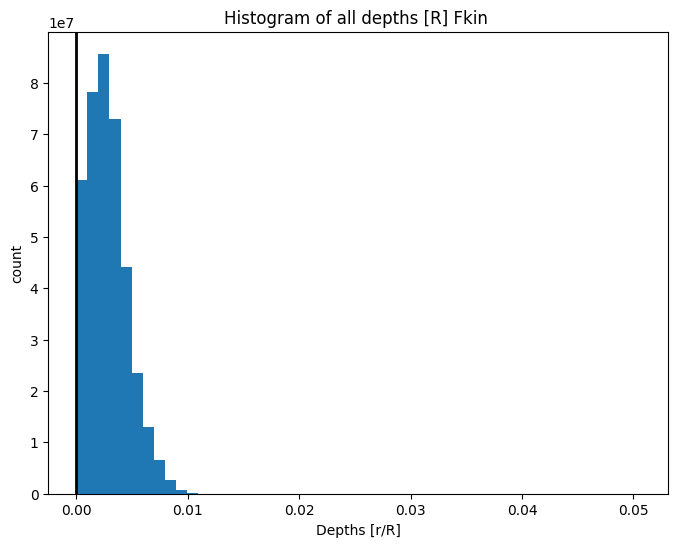

In [29]:
all_data["depth"] = - (all_data["r1"] - r_conv) / r_tot
bins = np.arange(0.0, 0.05+dr_grid/r_tot, dr_grid/r_tot)
plt.hist(all_data["depth"], bins=bins);
plt.xlabel('Depths [r/R]');
plt.ylabel('count');
plt.axvline(0.0, color="k", linewidth=2)
plt.title('Histogram of all depths [R] Fkin ')
avg=statistics.mean(all_data["depth"])
avghp=statistics.mean(all_data["depth"]*r_tot/Hp_conv)
print("Mean depth [R]=",avg,"Mean depth [Hp_conv]=",avghp)
plt.savefig(save_dir + 'bulk_kinetic.png')

Mean max. depth [R]= 0.01313109849417339   Mean max. depth [Hp_conv]= 0.16548212795308934


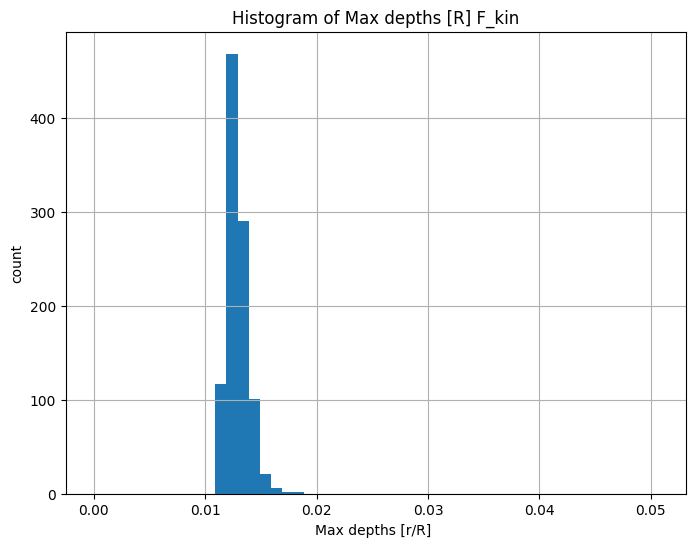

In [30]:
# max_depth = all_data["depth"].max(level="time")
max_depth = all_data["depth"].groupby(level="time").max()
max_depth.hist(bins=bins, density=True)
plt.xlabel('Max depths [r/R] ');
plt.ylabel('count');
#plt.xlim(0,0.1)
plt.title('Histogram of Max depths [R] F_kin')
avg=statistics.mean(max_depth)
avghp=statistics.mean(max_depth*r_tot/Hp_conv)
print("Mean max. depth [R]=",avg,"  Mean max. depth [Hp_conv]=",avghp)
plt.savefig(save_dir + 'max_kinetic.png')

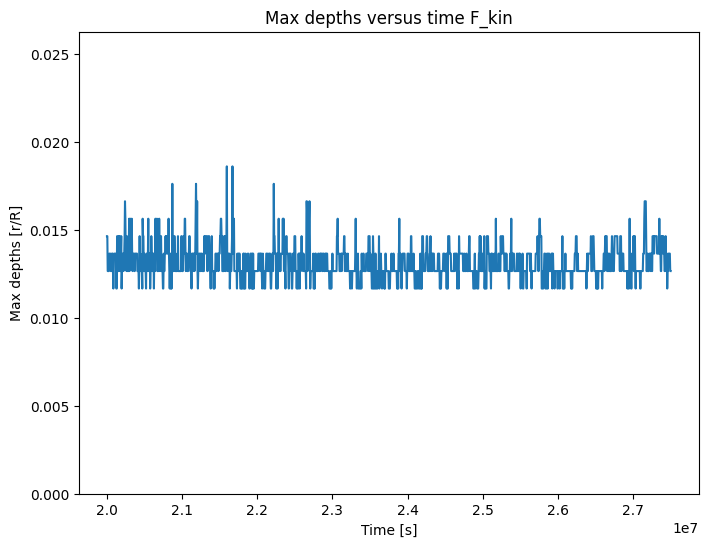

In [31]:
max_depth.plot()
plt.ylim(0,2*max_depth.mean())
plt.xlabel('Time [s]')
plt.ylabel('Max depths [r/R]')
plt.title('Max depths versus time F_kin')
plt.savefig(save_dir + 'time_kinetic.png')

Mean depth [R]= 0.002413628818482439 Mean depth [Hp_conv]= 0.03041729082406719


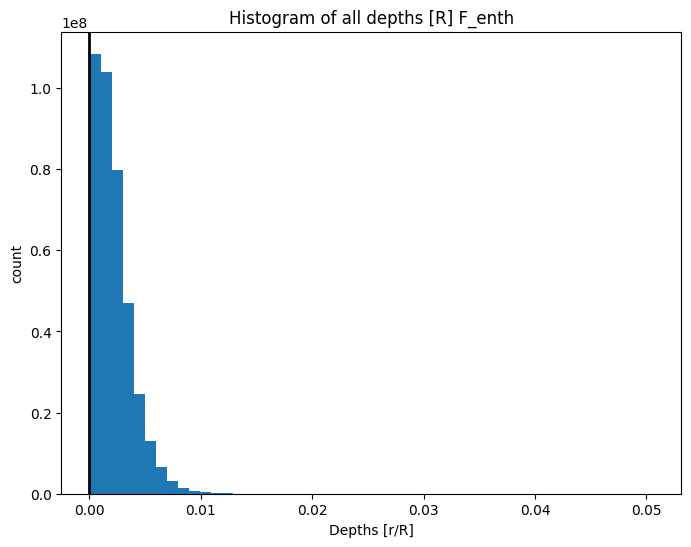

In [32]:
all_data["depth"] = - (all_data["r2"] - r_conv) / r_tot
bins = np.arange(0.0, 0.05+dr_grid/r_tot, dr_grid/r_tot)
plt.hist(all_data["depth"], bins=bins);
plt.xlabel('Depths [r/R]');
plt.ylabel('count');
plt.axvline(0.0, color="k", linewidth=2)
plt.title('Histogram of all depths [R] F_enth')
avg=statistics.mean(all_data["depth"])
avghp=statistics.mean(all_data["depth"]*r_tot/Hp_conv)
print("Mean depth [R]=",avg,"Mean depth [Hp_conv]=",avghp)
plt.savefig(save_dir + 'bulk_enth.png')

Mean max. depth [R]= 0.017353809140854198   Mean max. depth [Hp_conv]= 0.2186980257420939


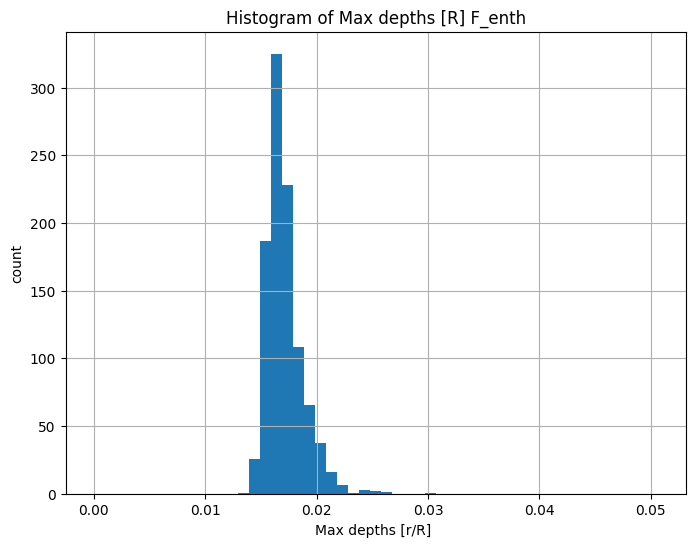

In [33]:
# max_depth = all_data["depth"].max(level="time")
max_depth = all_data["depth"].groupby(level="time").max()
max_depth.hist(bins=bins, density=True)
plt.xlabel('Max depths [r/R] ');
plt.ylabel('count');
#plt.xlim(0,0.1)
plt.title('Histogram of Max depths [R] F_enth')
avg=statistics.mean(max_depth)
avghp=statistics.mean(max_depth*r_tot/Hp_conv)
print("Mean max. depth [R]=",avg,"  Mean max. depth [Hp_conv]=",avghp)
plt.savefig(save_dir + 'max_enth.png')

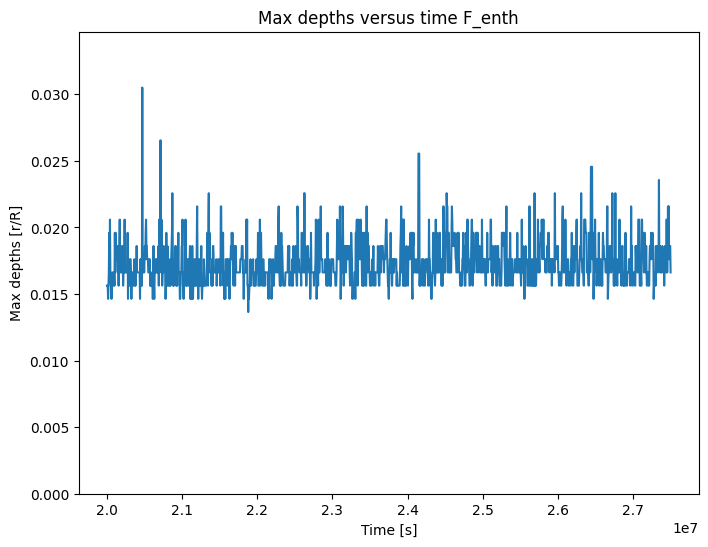

In [34]:
max_depth.plot()
plt.ylim(0,2 * max_depth.mean())
plt.xlabel('Time [s]')
plt.ylabel('Max depths [r/R]')
plt.title('Max depths versus time F_enth')
plt.savefig(save_dir + 'time_enth.png')

In [35]:
all_data

num_phi  phi_deg  theta_deg           HP1            r1  \
time       num_theta                                                            
19999950.0 1                1      0.2       30.2  5.615975e+09  5.144499e+10   
           1                2      0.5       30.2  5.615974e+09  5.144499e+10   
           1                3      0.8       30.2  5.615974e+09  5.144499e+10   
           1                4      1.2       30.2  5.615974e+09  5.144499e+10   
           1                5      1.5       30.2  5.615973e+09  5.144499e+10   
...                       ...      ...        ...           ...           ...   
27500170.0 360            716    238.5      149.8  5.615976e+09  5.137477e+10   
           360            717    238.8      149.8  5.615978e+09  5.137477e+10   
           360            718    239.2      149.8  5.615979e+09  5.137477e+10   
           360            719    239.5      149.8  5.615980e+09  5.137477e+10   
           360            720    239.8      149.8  5.615980e+09  5.137477e+10   

                                r2     depth  
time       num_theta                          
19999950.0 1          5.144499e+10  0.000752  
           1          5.144499e+10  0.000752  
           1          5.144499e+10  0.000752  
           1          5.144499e+10  0.000752  
           1          5.144499e+10  0.000752  
...                            ...       ...  
27500170.0 360        5.137477e+10  0.001744  
           360        5.137477e+10  0.001744  
           360        5.137477e+10  0.001744  
           360        5.137477e+10  0.001744  
           360        5.137477e+10  0.001744  

[389059038 rows x 7 columns]

## Latitude 2D histograms

In [45]:
theta_num = all_data.index.get_level_values(1).to_numpy()

In [19]:
new_df = all_data.set_index('num_phi', append=True)

In [47]:
all_data['depth']

time        num_theta
19999940.0  1            0.005712
            1            0.000752
            1            0.003728
            1            0.003728
            1            0.002736
                           ...   
22549900.0  360          0.002736
            360          0.002736
            360          0.002736
            360          0.003728
            360          0.004720
Name: depth, Length: 132451074, dtype: float64

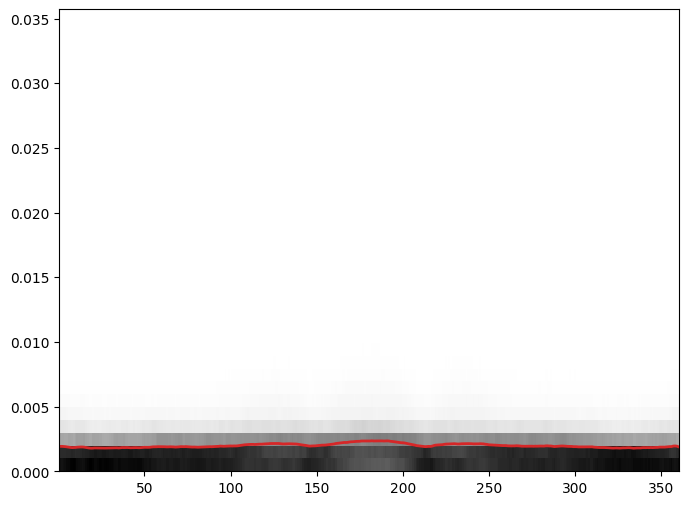

In [48]:
fig, ax = plt.subplots()
# plt.hist2d(all_data['theta_deg'].values, all_data['depth'].values, bins = [Ntheta,int(np.floor(0.035 * r_tot / dr_grid))])
h, __, __, img =ax.hist2d(theta_num, all_data['depth'].values, bins = [np.arange(0.5,361.5,1),np.arange(0.0, 0.035+dr_grid/r_tot, dr_grid/r_tot)], cmap='Greys')
# ax.scatter(np.arange(1,361), all_data.groupby(level='num_theta').mean()['depth'].values, marker='.')
ax.plot(np.arange(1,361), all_data.groupby(level='num_theta').mean()['depth'].values, lw=2, c='tab:red')

In [49]:
new_df['depth'].groupby(level=["time", "num_theta"]).max()

time        num_theta
19999940.0  1            0.010672
            2            0.009680
            3            0.010672
            4            0.011664
            5            0.011664
                           ...   
22549900.0  356          0.008688
            357          0.013649
            358          0.012657
            359          0.011664
            360          0.015633
Name: depth, Length: 183960, dtype: float64

In [50]:
new_df['depth'].groupby(level=["time", "num_theta"]).max().index.get_level_values(1).to_numpy()

array([  1,   2,   3, ..., 358, 359, 360], shape=(183960,))

In [51]:
max_results = new_df['depth'].groupby(level=["time", "num_theta"]).max()

In [52]:
max_results

time        num_theta
19999940.0  1            0.010672
            2            0.009680
            3            0.010672
            4            0.011664
            5            0.011664
                           ...   
22549900.0  356          0.008688
            357          0.013649
            358          0.012657
            359          0.011664
            360          0.015633
Name: depth, Length: 183960, dtype: float64

In [53]:
theta_num = max_results.index.get_level_values(1)

In [54]:
max_means = max_results.groupby(level='num_theta').mean().values

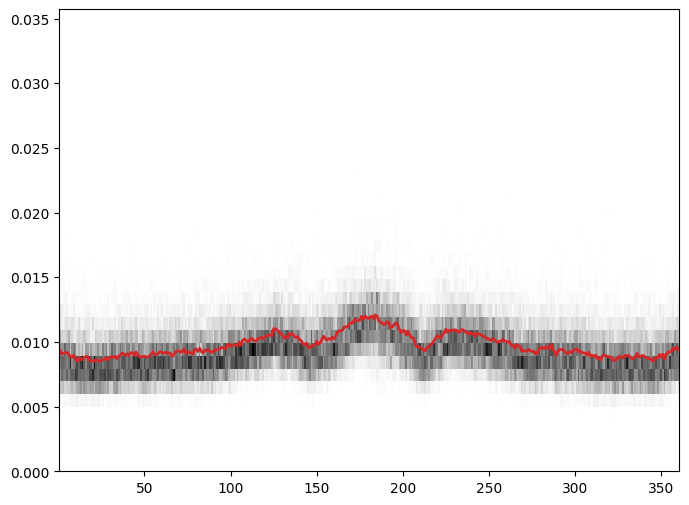

In [55]:
fig, ax = plt.subplots()
# plt.hist2d(all_data['theta_deg'].values, all_data['depth'].values, bins = [Ntheta,int(np.floor(0.035 * r_tot / dr_grid))])
h, __, __, img =ax.hist2d(theta_num, max_results.values, bins = [np.arange(0.5,361.5,1),np.arange(0.0, 0.035+dr_grid/r_tot, dr_grid/r_tot)], cmap='Greys')
# ax.scatter(np.arange(1,361), all_data.groupby(level='num_theta').mean()['depth'].values, marker='.')
ax.plot(np.arange(1,361), max_means, lw=2, c='tab:red')

## Max Locations

In [20]:
idx = new_df.groupby('time')['depth'].idxmax()
idx

time
19999940.0     (19999940.0, 59, 129)
20004960.0    (20004960.0, 225, 473)
20009940.0    (20009940.0, 243, 318)
20014960.0      (20014960.0, 145, 2)
20019970.0    (20019970.0, 104, 268)
                       ...          
27479880.0    (27479880.0, 191, 533)
27484860.0    (27484860.0, 191, 533)
27489870.0    (27489870.0, 179, 241)
27494890.0    (27494890.0, 171, 184)
27499870.0      (27499870.0, 4, 652)
Name: depth, Length: 1501, dtype: object

In [21]:
theta_array = [t[1] for t in idx]   # list of theta values
phi_array   = [t[2] for t in idx]

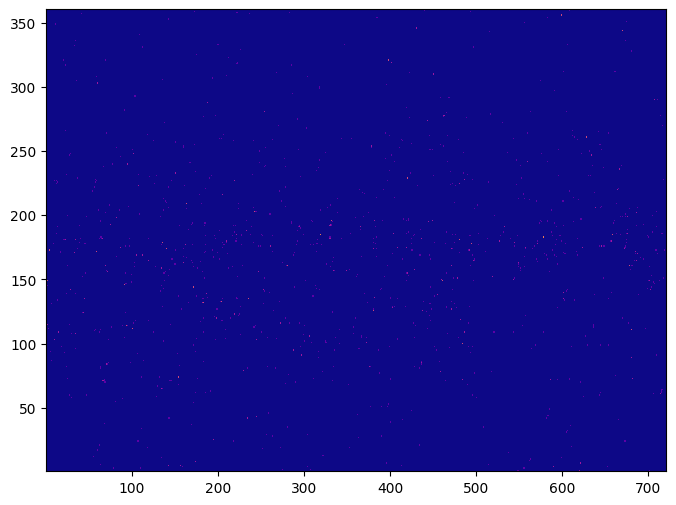

In [22]:
fig, ax = plt.subplots()
h, __, __, img =ax.hist2d(phi_array, theta_array, bins = [np.arange(0.5,721.5,1), np.arange(0.5,361.5,1)], cmap='plasma')

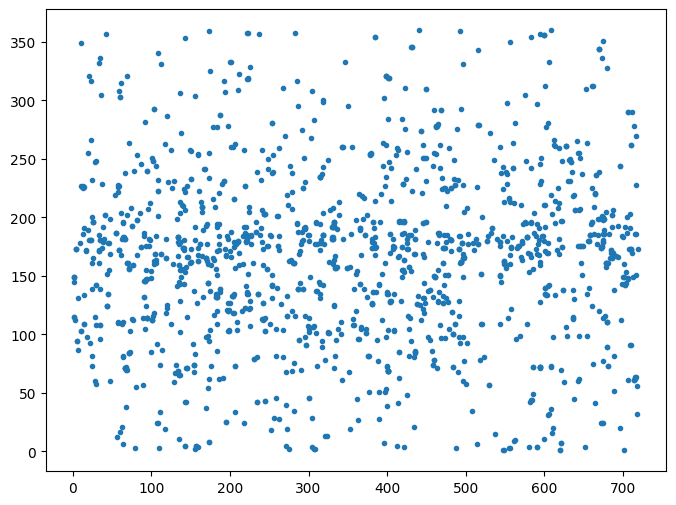

In [24]:
plt.scatter(phi_array, theta_array, marker='.')
plt.savefig('maxes_Om1.png')

## Horizontal mean depths

In [60]:
wvnw = new_df.groupby(level=["num_theta", "num_phi"])['depth'].mean()

In [61]:
theta_vals = wvnw.index.get_level_values(0)
phi_vals = wvnw.index.get_level_values(1)
vals = wvnw.values

In [62]:
phi_vals

Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,
       ...
       711, 712, 713, 714, 715, 716, 717, 718, 719, 720],
      dtype='int64', name='num_phi', length=259200)

In [63]:
phi_vals = np.reshape(phi_vals, (360,720))
theta_vals = np.reshape(theta_vals, (360,720))
vals = np.reshape(vals, (360,720))

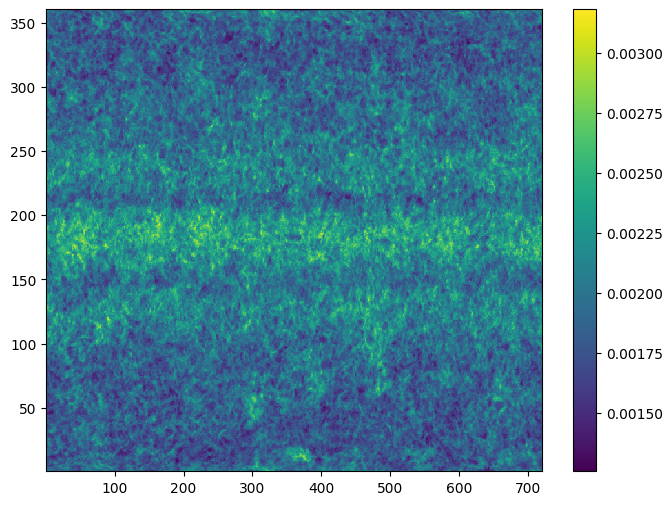

In [64]:
fig,ax = plt.subplots()
mesh = ax.pcolormesh(phi_vals, theta_vals, vals)
fig.colorbar(mesh)

In [65]:
new_df

phi_deg  theta_deg           HP1            r1  \
time       num_theta num_phi                                                   
19999940.0 1         1            0.2       30.2  5.615991e+09  5.144499e+10   
                     2            0.5       30.2  5.615990e+09  5.144499e+10   
                     3            0.8       30.2  5.615989e+09  5.109392e+10   
                     4            1.2       30.2  5.615988e+09  5.109392e+10   
                     5            1.5       30.2  5.615987e+09  5.109392e+10   
...                               ...        ...           ...           ...   
22549900.0 360       715        238.2      149.8  5.615978e+09  5.130456e+10   
                     716        238.5      149.8  5.615977e+09  5.130456e+10   
                     717        238.8      149.8  5.615976e+09  5.130456e+10   
                     718        239.2      149.8  5.615976e+09  5.123435e+10   
                     719        239.5      149.8  5.615975e+09  5.116414e+10   

                                        r2     depth  
time       num_theta num_phi                          
19999940.0 1         1        5.109392e+10  0.005712  
                     2        5.144499e+10  0.000752  
                     3        5.123435e+10  0.003728  
                     4        5.123435e+10  0.003728  
                     5        5.130456e+10  0.002736  
...                                    ...       ...  
22549900.0 360       715      5.130456e+10  0.002736  
                     716      5.130456e+10  0.002736  
                     717      5.130456e+10  0.002736  
                     718      5.123435e+10  0.003728  
                     719      5.116414e+10  0.004720  

[132451074 rows x 6 columns]

19999940.0
time        num_theta  num_phi
19999940.0  1          1          0.005712
                       2          0.000752
                       3          0.003728
                       4          0.003728
                       5          0.002736
                                    ...   
            360        716        0.002736
                       717        0.002736
                       718        0.001744
                       719        0.001744
                       720        0.001744
Name: depth, Length: 259200, dtype: float64
20004960.0
time        num_theta  num_phi
20004960.0  1          1          0.005712
                       2          0.005712
                       3          0.006704
                       4          0.003728
                       5          0.003728
                                    ...   
            360        716        0.002736
                       717        0.001744
                       718        0.001744
            

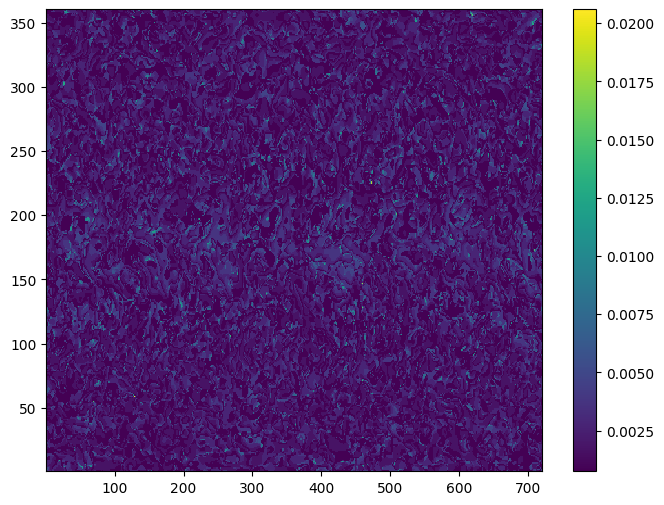

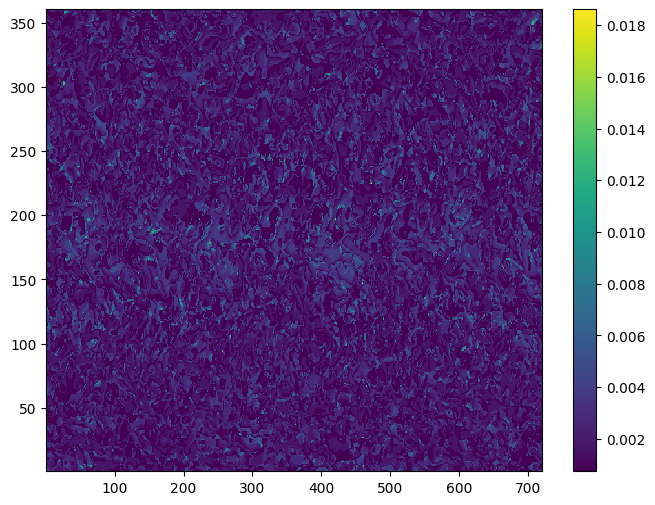

In [66]:
K = 0
for a_value, group in new_df['depth'].groupby(level='time'):
    # group contains all rows where index level A == a_value
    print(a_value)
    print(group)
    theta_vals = group.index.get_level_values(1)
    phi_vals = group.index.get_level_values(2)
    vals = group.values
    phi_vals = np.reshape(phi_vals, (360,720))
    theta_vals = np.reshape(theta_vals, (360,720))
    vals = np.reshape(vals, (360,720))
    fig,ax = plt.subplots()
    mesh = ax.pcolormesh(phi_vals, theta_vals, vals)
    fig.colorbar(mesh)
    K += 1
    if K >= 2:
        break

In [1]:
time = new_df.index.get_level_values(0).unique()

NameError: name 'new_df' is not defined

In [ ]:
from matplotlib.animation import FuncAnimation

In [ ]:
1000/20

In [ ]:
len(time) // 20

In [ ]:
fig, ax = plt.subplots()


i0 = 0

temp_table = new_df['depth'].xs(time[0], level='time')

phi_vals = temp_table.index.get_level_values(0)
theta_vals = temp_table.index.get_level_values(1)
phi_vals = np.reshape(phi_vals, (360,720))
theta_vals = np.reshape(theta_vals, (360,720))
vals = np.reshape(temp_table.values, (360,720))

mesh = ax.pcolormesh(theta_vals, phi_vals, vals, cmap='plasma')
fig.colorbar(mesh, ax=ax)

step = 5
def update(frame):
    i = frame * step                # because your loop used step=20
    if i >= len(time):
        return mesh               # stop condition (optional)
    
    ax.set_title(f'Checkpoint : {i}, {time[i]}')
    
    # Update the mesh data – this is much faster than recreating it
    temp_table = new_df['depth'].xs(time[i], level='time')
    vals = temp_table.values
    if vals.shape != (259200,):
        vals = np.zeros((259200,))
    
    mesh.set_array(np.reshape(vals, (360,720)))
    # Note: If your grid changes shape over time, you may need to update coordinates too
    return mesh,

n_frames = len(time) // step
anim = FuncAnimation(fig, update, frames=n_frames, interval=100, blit=True)

# To display the animation in a Jupyter notebook:
from IPython.display import HTML
HTML(anim.to_jshtml())

# Looking at excluding polar plumes
Going to make histograms with excluded 5 deg and 10 deg near border.

In [20]:
all_data["depth"] = - (all_data["r1"] - r_conv) / r_tot

In [21]:
df_5deg = all_data.query('35 <= theta_deg <= 145')

In [22]:
df_10deg = all_data.query('40 <= theta_deg <= 140')

AVERAGES
[r/R] : 0deg 0.003092063096370071, 5deg 0.0031100737567153294, 10deg 0.0031122780455384823


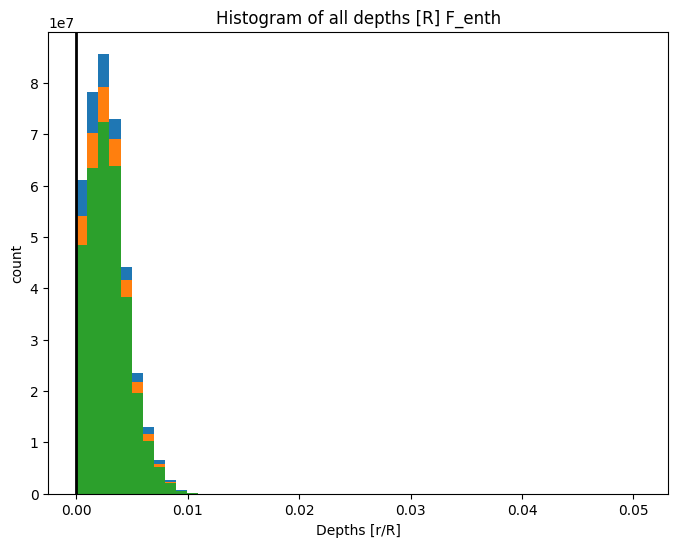

In [23]:
fig, ax = plt.subplots()
bins = np.arange(0.0, 0.05+dr_grid/r_tot, dr_grid/r_tot)

ax.hist(all_data["depth"], bins=bins);
ax.hist(df_5deg["depth"], bins=bins);
ax.hist(df_10deg["depth"], bins=bins);

ax.set_xlabel('Depths [r/R]');
ax.set_ylabel('count');
ax.axvline(0.0, color="k", linewidth=2)
ax.set_title('Histogram of all depths [R] F_enth')

avg = np.mean(all_data['depth'])
avg_5deg = np.mean(df_5deg['depth'])
avg_10deg = np.mean(df_10deg['depth'])
print("AVERAGES")
print(f"[r/R] : 0deg {avg}, 5deg {avg_5deg}, 10deg {avg_10deg}")
# print(f"[Hp_conv] : 0deg  {avg*r_tot/Hp_conv}, 5deg  {avg_5deg*r_tot/Hp_conv}, 10deg  {avg_10deg*r_tot/Hp_conv}")

AVERAGES
[r/R] : 0deg 0.013131098494173389, 5deg 0.01285746967752116, 10deg0.012647947504794048


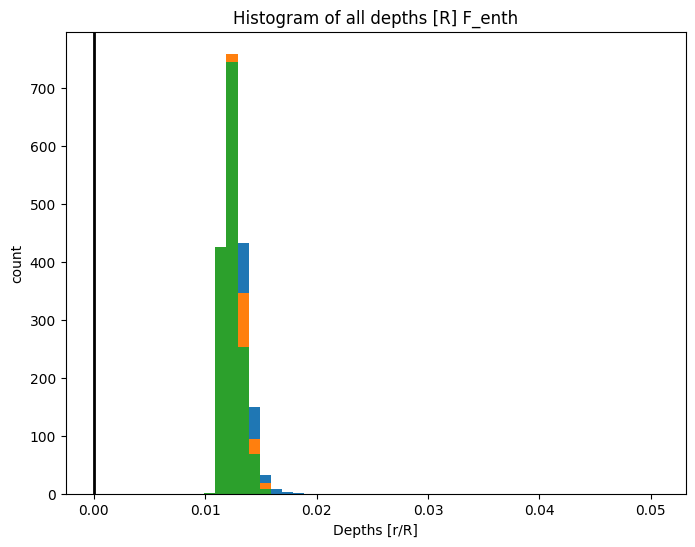

In [24]:
fig, ax = plt.subplots()
bins = np.arange(0.0, 0.05+dr_grid/r_tot, dr_grid/r_tot)

max_depth = all_data["depth"].groupby(level="time").max()
max_depth_5deg = df_5deg["depth"].groupby(level="time").max()
max_depth_10deg = df_10deg["depth"].groupby(level="time").max()

ax.hist(max_depth, bins=bins);
ax.hist(max_depth_5deg, bins=bins);
ax.hist(max_depth_10deg, bins=bins);

ax.set_xlabel('Depths [r/R]');
ax.set_ylabel('count');
ax.axvline(0.0, color="k", linewidth=2)
ax.set_title('Histogram of all depths [R] F_enth')

avg = np.mean(max_depth)
avg_5deg = np.mean(max_depth_5deg)
avg_10deg = np.mean(max_depth_10deg)
print("AVERAGES")
print(f"[r/R] : 0deg {avg}, 5deg {avg_5deg}, 10deg{avg_10deg}")
# print(f"[Hp_conv] : 0deg {avg*r_tot/Hp_conv}, 5deg {avg_5deg*r_tot/Hp_conv}, 10deg{avg_10deg*r_tot/Hp_conv}")

AVERAGES
[r/R] : 0deg 0.013131098494173389, 5deg 0.01285746967752116, 10deg0.012647947504794048


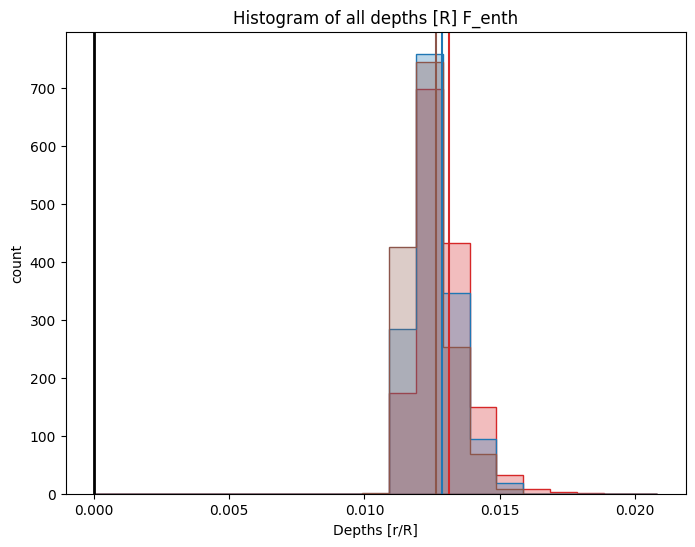

In [34]:
fig, ax = plt.subplots()
bins = np.arange(0.0, 0.02+dr_grid/r_tot, dr_grid/r_tot)

max_depth = all_data["depth"].groupby(level="time").max()
max_depth_5deg = df_5deg["depth"].groupby(level="time").max()
max_depth_10deg = df_10deg["depth"].groupby(level="time").max()

ax.hist(max_depth, bins=bins,histtype='stepfilled', edgecolor='tab:red', facecolor=('tab:red', 0.3));
ax.hist(max_depth_5deg, bins=bins,histtype='stepfilled', edgecolor='tab:blue', facecolor=('tab:blue', 0.3));
ax.hist(max_depth_10deg, bins=bins,histtype='stepfilled', edgecolor='tab:brown', facecolor=('tab:brown', 0.3));

ax.set_xlabel('Depths [r/R]');
ax.set_ylabel('count');
ax.axvline(0.0, color="k", linewidth=2)
ax.set_title('Histogram of all depths [R] F_enth')

avg = np.mean(max_depth)
avg_5deg = np.mean(max_depth_5deg)
avg_10deg = np.mean(max_depth_10deg)
print("AVERAGES")
print(f"[r/R] : 0deg {avg}, 5deg {avg_5deg}, 10deg{avg_10deg}")
# print(f"[Hp_conv] : 0deg {avg*r_tot/Hp_conv}, 5deg {avg_5deg*r_tot/Hp_conv}, 10deg{avg_10deg*r_tot/Hp_conv}")

ax.axvline(avg, c='tab:red')
ax.axvline(avg_5deg, c='tab:blue')
ax.axvline(avg_10deg, c='tab:brown')